In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallamahgoub/diabetes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes


In [ ]:
df = pd.read_csv("/kaggle/input/diabetes/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\nColumns")
print("=" * 50)
print(df.columns.tolist())

print("\nData Types")
print("=" * 50)
print(df.dtypes)

print("\nFirst 5 Rows")
print("=" * 50)
print(df.head())

Dataset Shape
(768, 9)

Columns
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']

Data Types
Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
Pedigree         float64
Age                int64
Outcome            int64
dtype: object

First 5 Rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   Pedigree  Age  Outcome  
0     0.627   50        1  
1     0.351   31        0  
2     0.672   32        1  
3     0.167   21        0  
4     2.288   33     

In [ ]:
# Missing Values Analysis

print("=" * 50)
print("Missing Values")
print("=" * 50)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

print(missing_df)

Missing Values
               Missing Values  Percentage
Pregnancies                 0         0.0
Glucose                     0         0.0
BloodPressure               0         0.0
SkinThickness               0         0.0
Insulin                     0         0.0
BMI                         0         0.0
Pedigree                    0         0.0
Age                         0         0.0
Outcome                     0         0.0


In [ ]:
z# Duplicate Records Analysis

print("=" * 50)
print("Duplicate Records")
print("=" * 50)

duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nRemoving duplicate rows...")
    df = df.drop_duplicates()
    print(f"New Dataset Shape: {df.shape}")
else:
    print("No duplicate rows found.")

Duplicate Records
Total Duplicate Rows: 0
No duplicate rows found.


In [ ]:
# Statistical Summary
print("=" * 50)
print("Statistical Summary")
print("=" * 50)

summary = df.describe().T

print(summary)


Statistical Summary
               count        mean         std     min       25%       50%  \
Pregnancies    768.0    3.845052    3.369578   0.000   1.00000    3.0000   
Glucose        768.0  120.894531   31.972618   0.000  99.00000  117.0000   
BloodPressure  768.0   69.105469   19.355807   0.000  62.00000   72.0000   
SkinThickness  768.0   20.536458   15.952218   0.000   0.00000   23.0000   
Insulin        768.0   79.799479  115.244002   0.000   0.00000   30.5000   
BMI            768.0   31.992578    7.884160   0.000  27.30000   32.0000   
Pedigree       768.0    0.471876    0.331329   0.078   0.24375    0.3725   
Age            768.0   33.240885   11.760232  21.000  24.00000   29.0000   
Outcome        768.0    0.348958    0.476951   0.000   0.00000    0.0000   

                     75%     max  
Pregnancies      6.00000   17.00  
Glucose        140.25000  199.00  
BloodPressure   80.00000  122.00  
SkinThickness   32.00000   99.00  
Insulin        127.25000  846.00  
BMI      

Target Variable Analysis
           Outcome  Count  Percentage
0  No Diabetes (0)    500        65.1
1     Diabetes (1)    268        34.9


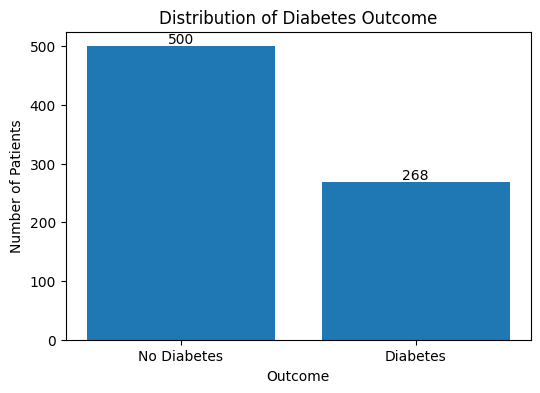

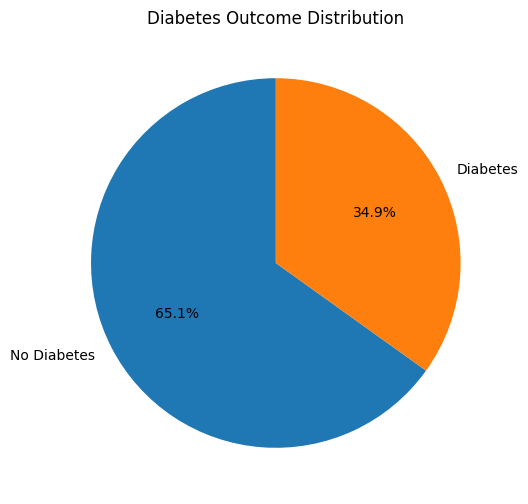

In [ ]:
# Target Variable Analysis
print("=" * 50)
print("Target Variable Analysis")
print("=" * 50)

target_count = df["Outcome"].value_counts().sort_index()

target_df = pd.DataFrame({
    "Outcome": ["No Diabetes (0)", "Diabetes (1)"],
    "Count": target_count.values,
    "Percentage": (target_count.values / len(df) * 100).round(2)
})

print(target_df)

# 📊 Visualization 1 — Bar Chart
plt.figure(figsize=(6,4))

plt.bar(
    ["No Diabetes", "Diabetes"],
    target_count.values
)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

for i, value in enumerate(target_count.values):
    plt.text(i, value + 5, str(value), ha='center')

plt.show()

# 📊 Visualization 2 — Pie Chart
plt.figure(figsize=(6,6))

plt.pie(
    target_count.values,
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Diabetes Outcome Distribution")

plt.show()


Hidden Missing Values (Zero Value Analysis)
         Feature  Zero Count  Percentage
0        Glucose           5        0.65
1  BloodPressure          35        4.56
2  SkinThickness         227       29.56
3        Insulin         374       48.70
4            BMI          11        1.43


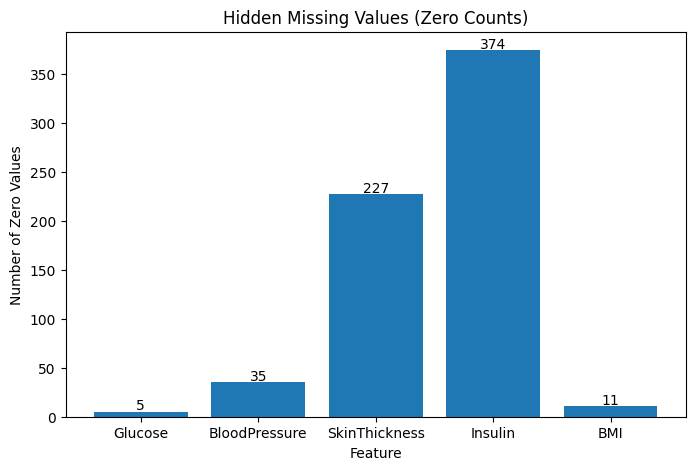

In [ ]:
# ==========================================
# Hidden Missing Values (Zero Value Analysis)
# ==========================================

print("=" * 50)
print("Hidden Missing Values (Zero Value Analysis)")
print("=" * 50)

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = pd.DataFrame({
    "Feature": zero_columns,
    "Zero Count": [ (df[col] == 0).sum() for col in zero_columns ]
})

zero_counts["Percentage"] = (
    zero_counts["Zero Count"] / len(df) * 100
).round(2)

print(zero_counts)

# 📊 Visualization

plt.figure(figsize=(8,5))

plt.bar(
    zero_counts["Feature"],
    zero_counts["Zero Count"]
)

plt.title("Hidden Missing Values (Zero Counts)")
plt.xlabel("Feature")
plt.ylabel("Number of Zero Values")

for i, value in enumerate(zero_counts["Zero Count"]):
    plt.text(i, value + 2, str(value), ha="center")

plt.show()

In [ ]:

# ==========================================
# Handle Hidden Missing Values
# ==========================================

columns_to_replace = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace 0 with NaN
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)

# Fill missing values using median
for column in columns_to_replace:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

print("Hidden missing values handled successfully.")


print("=" * 50)
print("Verification After Cleaning")
print("=" * 50)

print(df[columns_to_replace].isnull().sum())

print("\nZero Values Remaining:")
print((df[columns_to_replace] == 0).sum())


Hidden missing values handled successfully.
Verification After Cleaning
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Zero Values Remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


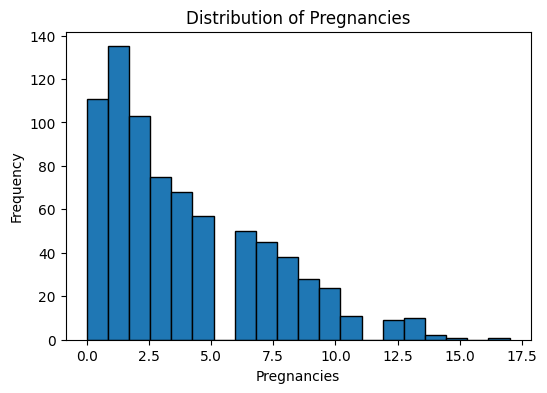

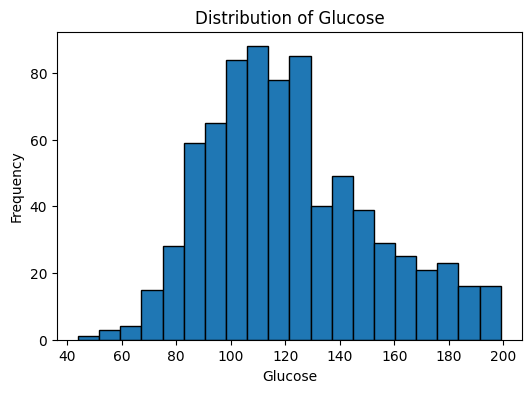

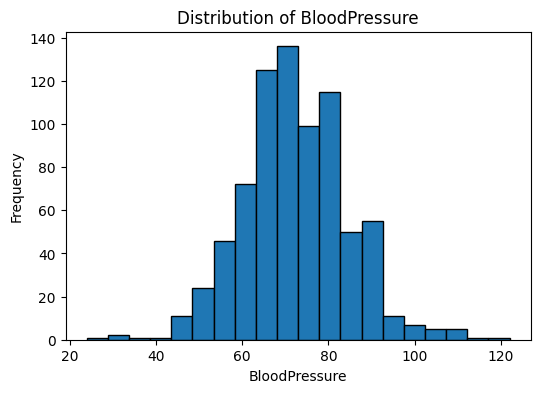

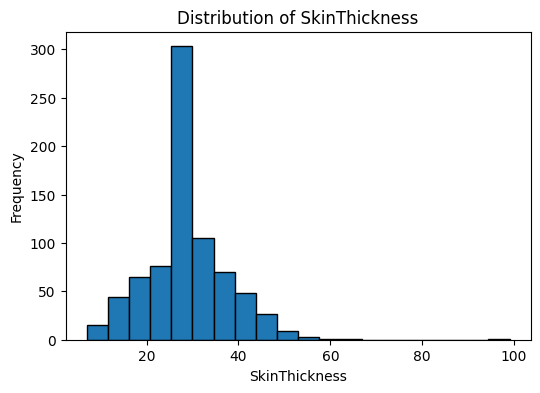

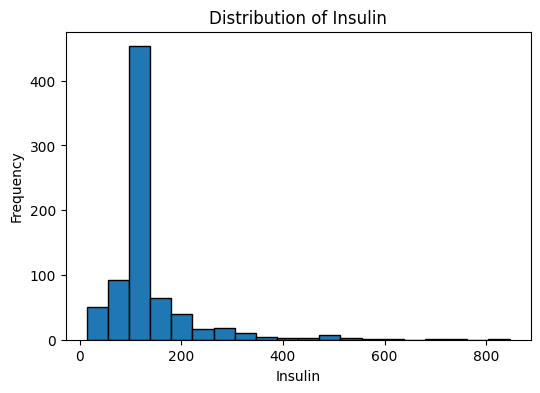

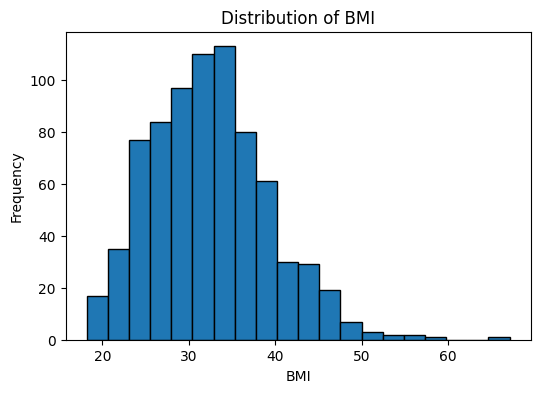

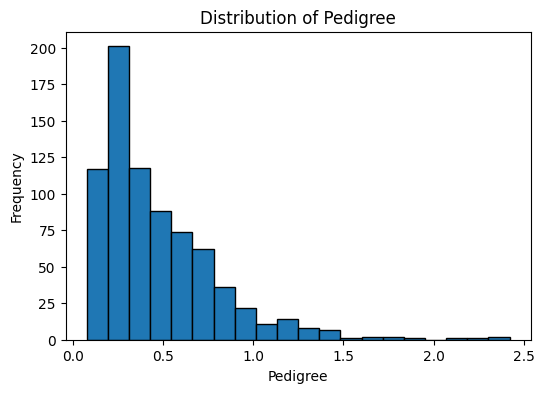

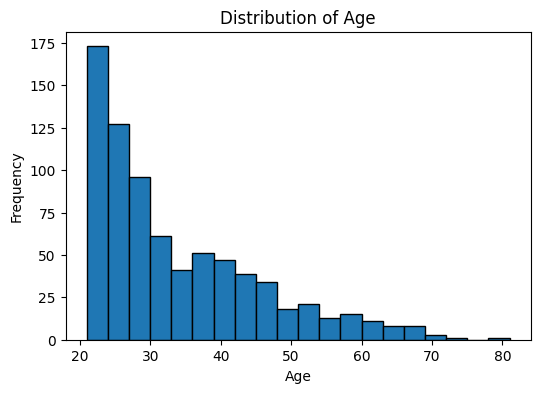

In [ ]:
# ==========================================
# Univariate Analysis
# ==========================================
numerical_columns = df.drop("Outcome", axis=1).columns


for column in numerical_columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[column], bins=20, edgecolor="black")

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

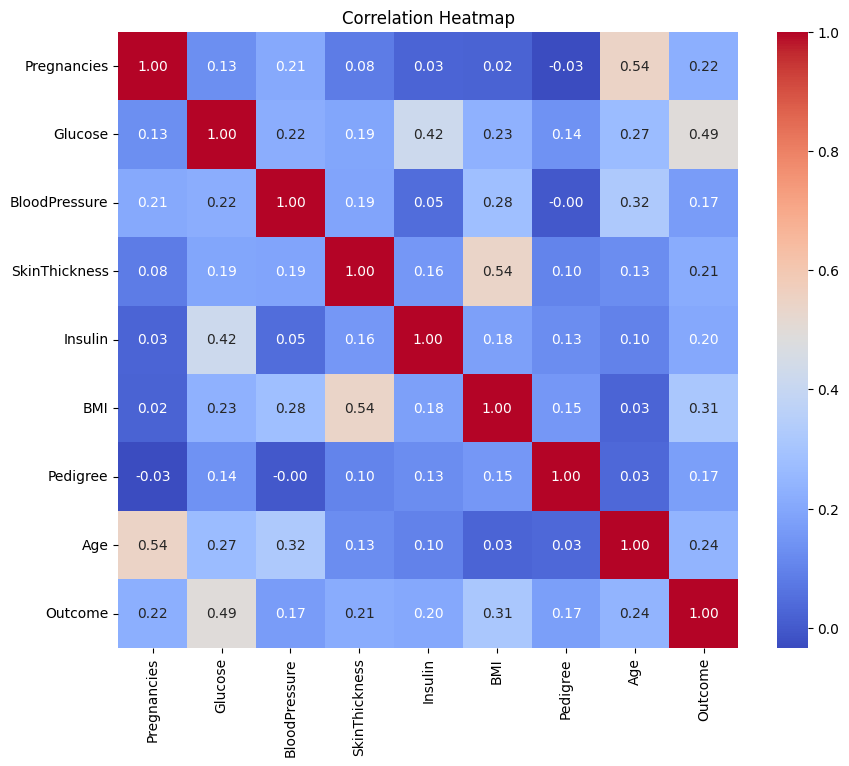

In [ ]:
# ==========================================
# Correlation Analysis
# ==========================================

plt.figure(figsize=(10,8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

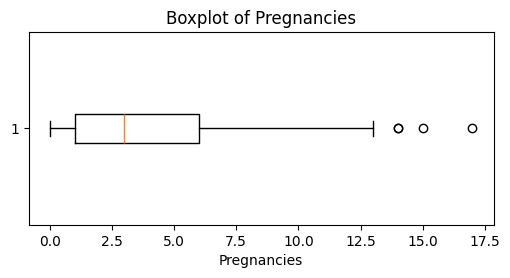

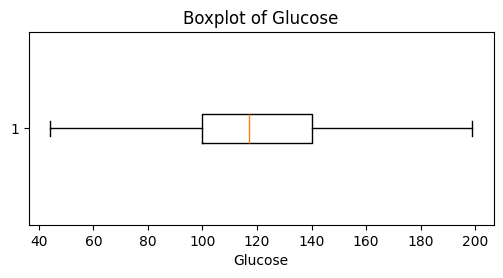

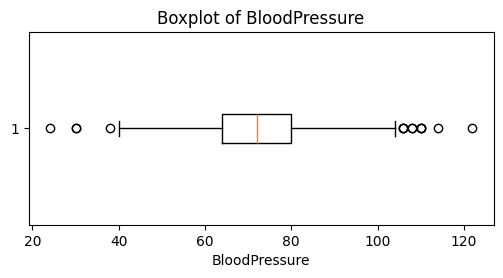

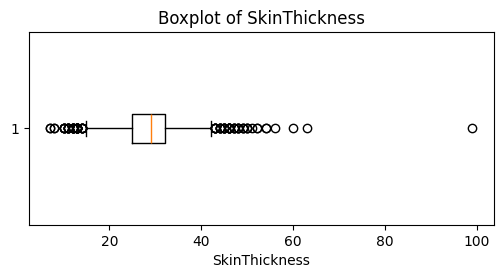

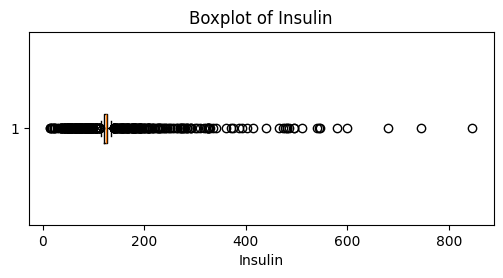

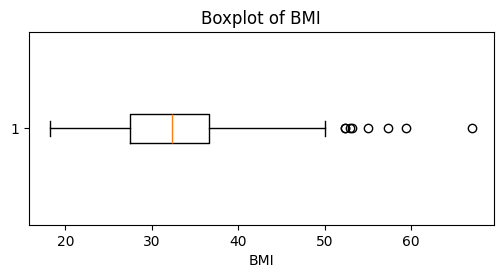

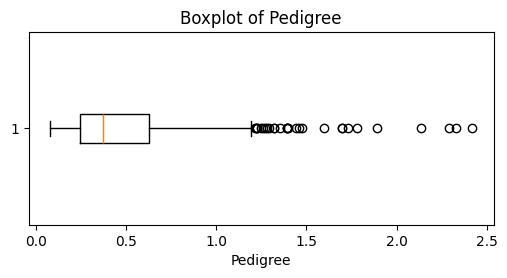

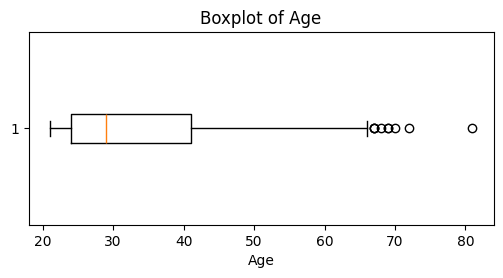

In [ ]:
# ==========================================
# Outlier Analysis
# ==========================================

numerical_columns = df.drop("Outcome", axis=1).columns

for column in numerical_columns:

    plt.figure(figsize=(6,2.5))

    plt.boxplot(df[column], vert=False)

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [ ]:
# ==========================================
# Feature and Target Split
# ==========================================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (768, 8)
Target Vector Shape  : (768,)


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (614, 8)
Testing Set  : (154, 8)


In [ ]:
# ==========================================
# Baseline Decision Tree Model
# ==========================================

baseline_dt = DecisionTreeClassifier(random_state=42)

baseline_dt.fit(X_train, y_train)

print("Baseline Decision Tree model trained successfully.")

Baseline Decision Tree model trained successfully.


In [ ]:
# ==========================================
# Cross Validation
# ==========================================

cv_scores = cross_val_score(
    baseline_dt,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("=" * 50)
print("Cross Validation Results")
print("=" * 50)

print("Fold Accuracies :", np.round(cv_scores, 4))
print("Mean Accuracy   :", round(cv_scores.mean(), 4))
print("Standard Deviation :", round(cv_scores.std(), 4))

Cross Validation Results
Fold Accuracies : [0.7208 0.6623 0.6429 0.7647 0.7647]
Mean Accuracy   : 0.7111
Standard Deviation : 0.0507


In [ ]:
# ==========================================
# Hyperparameter Tuning
# ==========================================

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 4, 5],
    "min_samples_split": [2, 3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_

print("=" * 50)
print("Best Hyperparameters")
print("=" * 50)

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid_search.best_score_, 4))


Best Hyperparameters
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.7477


Model Evaluation
Test Accuracy : 0.6883

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154


Confusion Matrix
[[92  8]
 [40 14]]


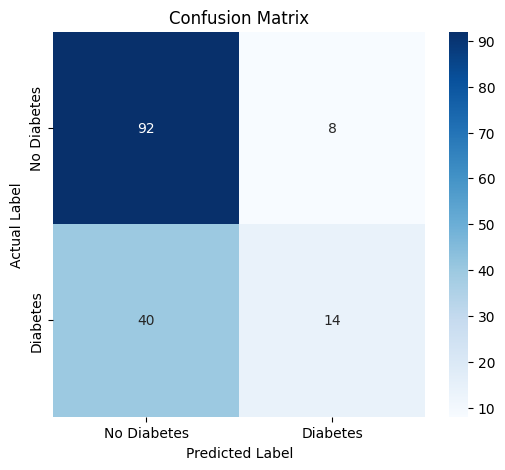

In [ ]:
# ==========================================
# Model Evaluation
# ==========================================

y_pred = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("=" * 50)
print("Model Evaluation")
print("=" * 50)

print(f"Test Accuracy : {accuracy:.4f}")

print("\nClassification Report")
print(class_report)

print("\nConfusion Matrix")
print(conf_matrix)

plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Feature Importance
         Feature  Importance
1        Glucose    0.695568
5            BMI    0.269789
4        Insulin    0.034643
0    Pregnancies    0.000000
3  SkinThickness    0.000000
2  BloodPressure    0.000000
6       Pedigree    0.000000
7            Age    0.000000


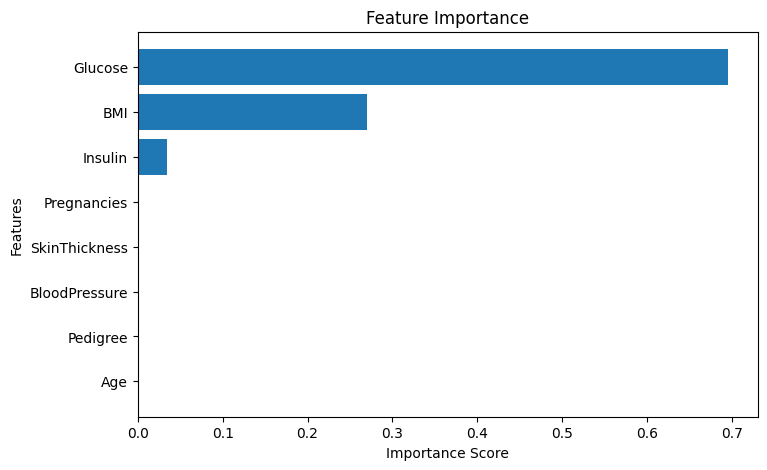

In [ ]:
# ==========================================
# Feature Importance Analysis
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 50)
print("Feature Importance")
print("=" * 50)

print(feature_importance)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

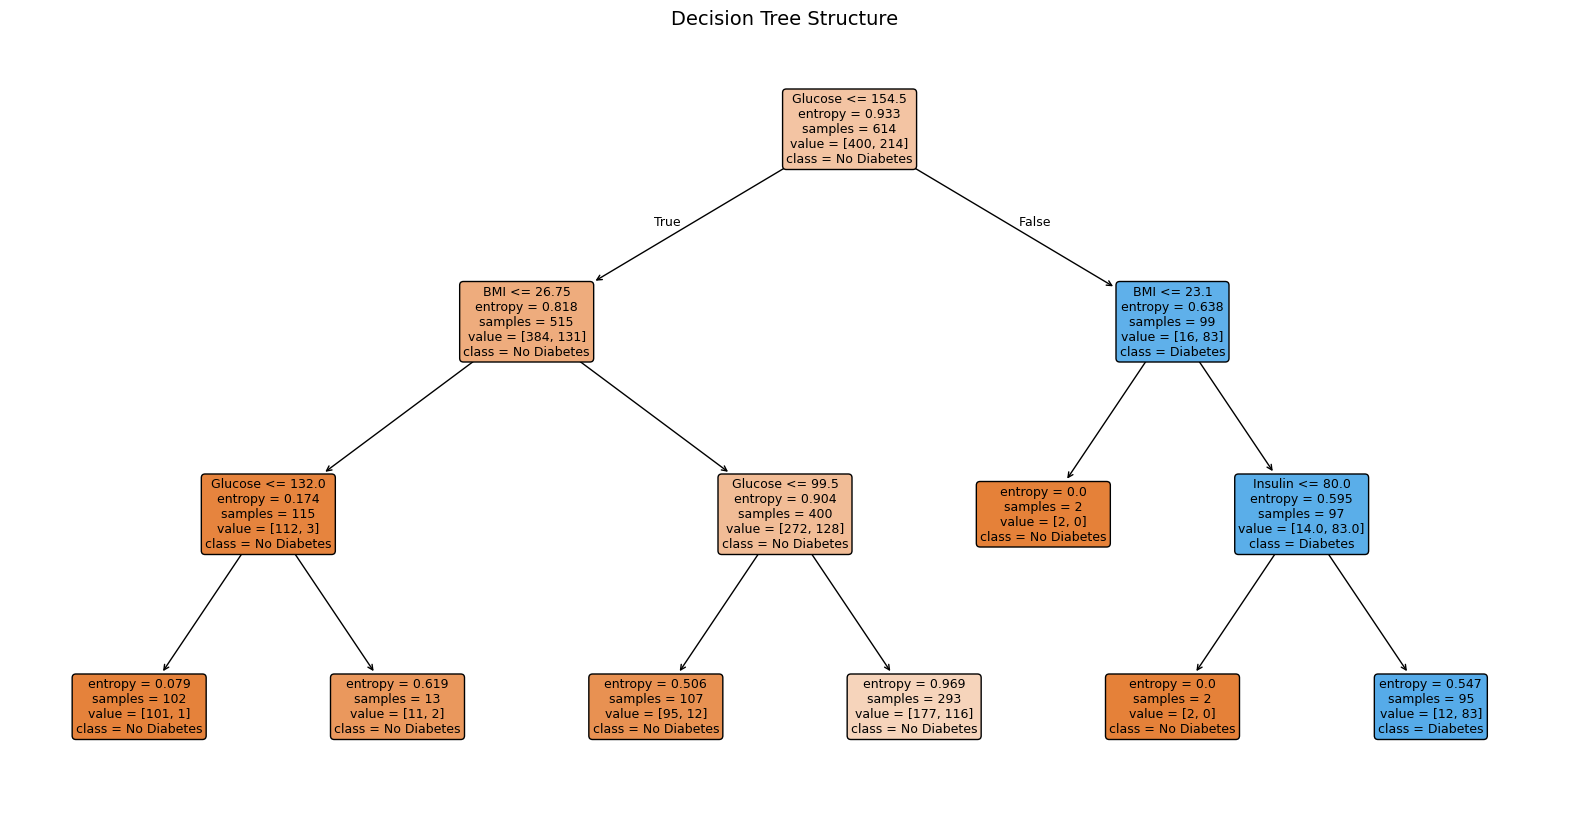

In [ ]:
# ==========================================
# Decision Tree Visualization
# ==========================================

plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Structure", fontsize=14)

plt.show()

In [ ]:
# ==========================================
# Save Trained Model
# ==========================================

joblib.dump(best_dt, "diabetes_decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# ==========================================
# Project Conclusion
# ==========================================

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("""
✓ Loaded and explored the Diabetes dataset.

✓ Performed Exploratory Data Analysis (EDA).

✓ Identified hidden missing values represented as zeros.

✓ Replaced invalid zero values using median imputation.

✓ Built a baseline Decision Tree model.

✓ Improved the model using GridSearchCV.

✓ Evaluated the model using:
    - Accuracy
    - Classification Report
    - Confusion Matrix

✓ Analyzed Feature Importance.

✓ Visualized the Decision Tree.

✓ Saved the trained model for future deployment.
""")

PROJECT SUMMARY

✓ Loaded and explored the Diabetes dataset.

✓ Performed Exploratory Data Analysis (EDA).

✓ Identified hidden missing values represented as zeros.

✓ Replaced invalid zero values using median imputation.

✓ Built a baseline Decision Tree model.

✓ Improved the model using GridSearchCV.

✓ Evaluated the model using:
    - Accuracy
    - Classification Report
    - Confusion Matrix

✓ Analyzed Feature Importance.

✓ Visualized the Decision Tree.

✓ Saved the trained model for future deployment.

